1. What is IoT?

IoT (Internet of Things) = Devices (sensors/actuators) + Connectivity (Wi-Fi/MQTT/HTTP) + Cloud/Server + Data Processing.

In real IoT:

Sensors collect data (temperature, motion, etc.)

Devices send data to the cloud (MQTT/HTTP)

Cloud processes and stores data

Applications analyze and visualize

Since you don’t have hardware, we’ll simulate sensors with random data in Jupyter.

2. Simulating Sensors (No Hardware)

In [1]:
import random
import time

# Simulated sensors
def get_temperature():
    return round(random.uniform(20, 35), 2)  # Celsius

def get_humidity():
    return round(random.uniform(30, 70), 2)  # %

# Collect readings
for i in range(5):
    temp = get_temperature()
    hum = get_humidity()
    print(f"Reading {i+1}: Temperature={temp}°C, Humidity={hum}%")
    time.sleep(1)


Reading 1: Temperature=26.35°C, Humidity=51.86%
Reading 2: Temperature=25.12°C, Humidity=33.47%
Reading 3: Temperature=29.55°C, Humidity=30.18%
Reading 4: Temperature=32.81°C, Humidity=52.41%
Reading 5: Temperature=33.39°C, Humidity=44.66%


3. Storing IoT Data (Local Database)

We often store IoT readings in a database. For simulation, we’ll use SQLite.

In [2]:
import sqlite3
import datetime

# Create DB
conn = sqlite3.connect("iot_data.db")
cur = conn.cursor()

# Create table
cur.execute("""
CREATE TABLE IF NOT EXISTS sensor_data (
    timestamp TEXT,
    temperature REAL,
    humidity REAL
)
""")

# Insert simulated readings
for _ in range(5):
    temp = get_temperature()
    hum = get_humidity()
    ts = datetime.datetime.now().isoformat()
    cur.execute("INSERT INTO sensor_data VALUES (?, ?, ?)", (ts, temp, hum))
    conn.commit()

print("Data inserted into database!")


Data inserted into database!


4. Visualizing IoT Data (Graphs)

IoT dashboards visualize trends. Let’s use matplotlib.

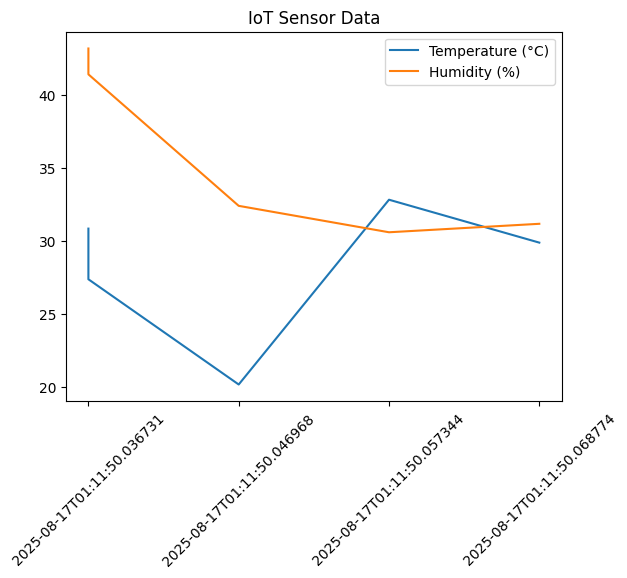

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load from DB
df = pd.read_sql_query("SELECT * FROM sensor_data", conn)

# Plot
plt.plot(df["timestamp"], df["temperature"], label="Temperature (°C)")
plt.plot(df["timestamp"], df["humidity"], label="Humidity (%)")
plt.xticks(rotation=45)
plt.legend()
plt.title("IoT Sensor Data")
plt.show()


5. IoT Communication with MQTT (Simulation)

IoT devices often use MQTT to talk to servers.
We can simulate MQTT with paho-mqtt.



In [7]:
import paho.mqtt.client as mqtt
import json

# MQTT broker (free public broker)
broker = "test.mosquitto.org"
topic = "demo/iot/sensor"

# Publisher
client = mqtt.Client()
client.connect(broker, 1883, 60)

for i in range(3):
    data = {"temperature": get_temperature(), "humidity": get_humidity()}
    client.publish(topic, json.dumps(data))
    print("Published:", data)


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_3512\1408454722.py:9: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Published: {'temperature': 26.83, 'humidity': 63.5}
Published: {'temperature': 22.55, 'humidity': 41.84}
Published: {'temperature': 31.96, 'humidity': 57.66}
